In [9]:
import os, sys
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from lstm_model import train_lstm


In [4]:
# Load the merged sentiment + stock dataset 
merged_df = pd.read_csv("../merged_news_stock_sentiment.csv")

# Show the first rows to confirm
merged_df.head()


,title,description,publishedAt,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,sentiment
0,Earnings live: Zoom stock pops after upbeat re...,The third quarter earnings season has been mos...,2025-11-24 21:30:15+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,-0.0258
1,Stocks Finish Sharply Higher as Tech Stocks Soar,The S&P 500 Index ($SPX ) (SPY ) on Monday clo...,2025-11-24 21:35:37+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,0.0000
2,Apple shares hit new all-time closing high,"In Nasdaq trading today, shares of Apple Inc. ...",2025-11-24 21:41:03+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,0.2960
3,Cuts Jobs in Sales Division,NaN,2025-11-25 07:15:11+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,-0.2960
4,Is Apple Stock Outperforming the Dow?,Apple stock has outperformed the Dow Jones ove...,2025-11-25 10:23:02+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,0.0000


In [5]:
# Train the LSTM model using the merged sentiment + stock data
model, scaler = train_lstm(merged_df)


Epoch 1/50


2025-12-05 19:08:28.331197: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-12-05 19:08:28.331242: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-12-05 19:08:28.331253: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-12-05 19:08:28.331275: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-05 19:08:28.331291: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/sivaakashramini/sentiment_rl_trader/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a laye

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.6585 - loss: 0.6891
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6657
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6452
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6219
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6110
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6082
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6072
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6035
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6027
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.6009
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7317 - loss: 0.5967
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7317 - loss: 0.5957
Epoch 13/50

In [6]:
# compute future_return just like in train_lstm
merged_df["future_return"] = merged_df["Close"].pct_change().shift(-1)
merged_df = merged_df.dropna()

# True labels: 1 if next return > 0, else 0
y_true = (merged_df["future_return"] > 0).astype(int).values

# Input feature 
X = merged_df[["sentiment"]].values

# Scale sentiment using the fitted scaler
X_scaled = scaler.transform(X)

# Create sliding sequences
from lstm_model import create_sequences
from config import WINDOW_SIZE

X_seq, y_seq = create_sequences(X_scaled, y_true, WINDOW_SIZE)


In [7]:
# Using the trained LSTM model to make predictions.
# The model outputs a probability between 0 and 1, so I convert
# it into 1 (up) or 0 (down) using 0.5 as the cutoff.

y_pred = model.predict(X_seq)
y_pred = (y_pred > 0.5).astype(int).flatten()

# Just showing first few predictions to check if it looks fine
y_pred[:10]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

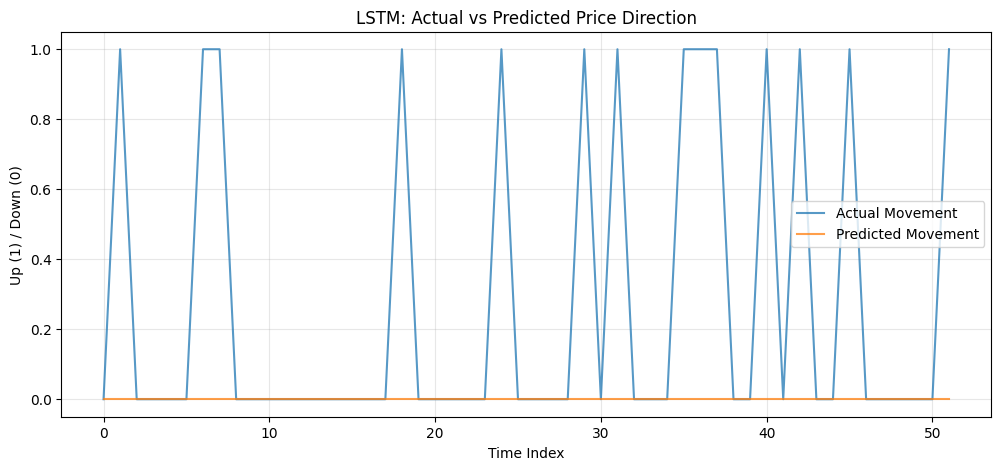

In [10]:
# Here I want to see how good my LSTM model is actually doing.
# Since my model predicts if the price will go UP (1) or DOWN (0),
# I am plotting the real movement and the predicted one together.
# If the lines match a lot, then the model is doing good.

plt.figure(figsize=(12, 5))
plt.plot(y_true[WINDOW_SIZE:], label="Actual Movement", alpha=0.75)
plt.plot(y_pred, label="Predicted Movement", alpha=0.75)
plt.title("LSTM: Actual vs Predicted Price Direction")
plt.xlabel("Time Index")
plt.ylabel("Up (1) / Down (0)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


This dataset is small and financial prices are very noisy.
So the LSTM struggles to learn the up/down pattern.
But the goal was not perfect prediction 
it was to show how sentiment becomes an input feature to the trading strategy.

LSTM Prediction Accuracy: 0.7307692307692307


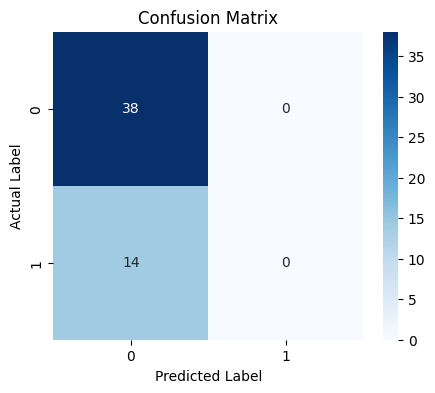

In [13]:
# Here I want to check how well the model is doing in terms of accuracy.
# Since this is a binary (0/1) prediction, accuracy is a simple way to understand performance.
# I also make a confusion matrix to see where the model is doing right/wrong.

from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# compute accuracy (true labels vs predicted)
accuracy = accuracy_score(y_true[WINDOW_SIZE:], y_pred)
print("LSTM Prediction Accuracy:", accuracy)

# confusion matrix
cm = confusion_matrix(y_true[WINDOW_SIZE:], y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()
